# Gradient Field PCA

### Key Insight
- **Real images**: Coherent gradients with natural 1/f spectrum
- **Synthetic images**: Micro-incoherence and spectral artifacts

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# data_dir = "/content/drive/MyDrive/datasets/OpenFake"

In [66]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Find repo root (works from notebooks/ directory)
def find_repo_root(start: Path, max_hops: int = 5) -> Path:
    p = start.resolve()
    markers = ["datasets", ".git", "notebooks"]
    for _ in range(max_hops):
        if any((p / m).exists() for m in markers):
            return p
        p = p.parent
    return start.resolve()

REPO_ROOT = find_repo_root(Path.cwd())
data_dir = REPO_ROOT / "datasets" / "OpenFake"

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir:  {data_dir}")
print(f"Exists:    {data_dir.exists()}")

# Configuration
IMG_SIZE = 256  # Fixed resolution
np.random.seed(42)

Repo root: /Users/andrewwu/Desktop/DeepFakeDetector
Data dir:  /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake
Exists:    True


---
## 2. Preprocessing

In [67]:
def load_and_preprocess(img_path: str, img_size: int = IMG_SIZE) -> np.ndarray:
    """Load image, resize, convert to luminance (BT.709)."""
    img = Image.open(img_path).convert('RGB')
    img = img.resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    
    R_COEFF, G_COEFF, B_COEFF = 0.2126, 0.7152, 0.0722
    luminance = R_COEFF * img_array[:,:,0] + G_COEFF * img_array[:,:,1] + B_COEFF * img_array[:,:,2]
    return luminance

---
## 3. Gradient Extraction & Analysis Functions

In [68]:
def compute_gradients(luminance: np.ndarray) -> tuple:
    """Compute Sobel gradients."""
    G_x = ndimage.sobel(luminance, axis=1, mode='reflect')
    G_y = ndimage.sobel(luminance, axis=0, mode='reflect')
    return G_x, G_y


def compute_coherence(G_x: np.ndarray, G_y: np.ndarray, sigma: float = 2.0) -> np.ndarray:
    """
    Compute local gradient coherence using structure tensor.
    
    High coherence = gradients are aligned (real edges)
    Low coherence = gradients are random (noise/artifacts)
    
    κ = ((λ₁ - λ₂) / (λ₁ + λ₂))²
    """
    # Structure tensor components
    Gxx = G_x * G_x
    Gxy = G_x * G_y
    Gyy = G_y * G_y
    
    # Smooth with Gaussian (local averaging)
    Sxx = ndimage.gaussian_filter(Gxx, sigma=sigma)
    Sxy = ndimage.gaussian_filter(Gxy, sigma=sigma)
    Syy = ndimage.gaussian_filter(Gyy, sigma=sigma)
    
    # Eigenvalues of 2x2 structure tensor
    trace = Sxx + Syy
    det_term = np.sqrt((Sxx - Syy)**2 + 4 * Sxy**2 + 1e-10)
    
    lambda1 = 0.5 * (trace + det_term)  # Larger
    lambda2 = 0.5 * (trace - det_term)  # Smaller
    
    # Coherence: 1 = perfect alignment, 0 = isotropic
    coherence = ((lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10))**2
    
    return coherence


def compute_power_spectrum(img: np.ndarray) -> tuple:
    """
    Compute radially averaged power spectrum.
    
    Natural images follow ~1/f² falloff.
    AI images may deviate at high frequencies.
    """
    # 2D FFT
    F = np.fft.fft2(img)
    F_shifted = np.fft.fftshift(F)
    power = np.abs(F_shifted)**2
    
    # Radial average
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    
    max_r = min(cx, cy)
    radial_power = np.zeros(max_r)
    for i in range(max_r):
        mask = r == i
        if mask.sum() > 0:
            radial_power[i] = power[mask].mean()
    
    frequencies = np.arange(max_r)
    return frequencies, radial_power


def normalize_gradients(G_x: np.ndarray, G_y: np.ndarray) -> tuple:
    """Normalize gradients to zero mean and unit variance."""
    G_x_norm = (G_x - G_x.mean()) / (G_x.std() + 1e-8)
    G_y_norm = (G_y - G_y.mean()) / (G_y.std() + 1e-8)
    return G_x_norm, G_y_norm


def extract_gradient_features(img_path: str, img_size: int = IMG_SIZE) -> np.ndarray:
    """Full pipeline: load -> luminance -> gradients -> flatten."""
    luminance = load_and_preprocess(img_path, img_size)
    G_x, G_y = compute_gradients(luminance)
    G_x_norm, G_y_norm = normalize_gradients(G_x, G_y)
    v = np.concatenate([G_x_norm.flatten(), G_y_norm.flatten()])
    return v

---
## 4. Visualization: Real vs Fake (Coherence & Spectrum)

This visualization shows the **discriminative features**:
1. **Coherence map** - Shows gradient alignment (real = coherent edges, fake = less coherent)
2. **Power spectrum** - Shows frequency distribution (natural 1/f vs artifacts)
3. **Local variance** - Shows micro-texture differences

In [69]:
def visualize_gradient_comparison(real_path: str, fake_path: str):
    """
    Comprehensive visualization comparing Real vs Fake gradient characteristics.
    Shows coherence maps, power spectra, and statistics.
    """
    fig = plt.figure(figsize=(22, 14))
    
    # Collect stats for comparison
    stats = {'real': {}, 'fake': {}}
    
    for col, (path, label, key) in enumerate([
        (real_path, 'REAL', 'real'), 
        (fake_path, 'FAKE', 'fake')
    ]):
        # Load and process
        img = Image.open(path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img)
        luminance = load_and_preprocess(path)
        G_x, G_y = compute_gradients(luminance)
        magnitude = np.sqrt(G_x**2 + G_y**2)
        coherence = compute_coherence(G_x, G_y)
        freqs, power = compute_power_spectrum(luminance)
        
        # Store stats
        stats[key]['coherence_mean'] = coherence.mean()
        stats[key]['coherence_std'] = coherence.std()
        stats[key]['magnitude_mean'] = magnitude.mean()
        stats[key]['power'] = power
        stats[key]['freqs'] = freqs
        
        # Local gradient variance (high-pass features)
        local_var = ndimage.generic_filter(magnitude, np.var, size=5)
        
        # Row 1: Original, Magnitude, Coherence
        ax1 = fig.add_subplot(3, 4, col*2 + 1)
        ax1.imshow(img_array)
        ax1.set_title(f'{label}: Original', fontsize=12, fontweight='bold')
        ax1.axis('off')
        
        ax2 = fig.add_subplot(3, 4, col*2 + 2)
        im = ax2.imshow(magnitude, cmap='hot')
        ax2.set_title(f'{label}: Gradient Magnitude\nmean={magnitude.mean():.4f}', fontsize=11)
        ax2.axis('off')
        plt.colorbar(im, ax=ax2, fraction=0.046)
        
        # Row 2: Coherence, Local Variance
        ax3 = fig.add_subplot(3, 4, 4 + col*2 + 1)
        im = ax3.imshow(coherence, cmap='viridis', vmin=0, vmax=1)
        ax3.set_title(f'{label}: Coherence κ\nmean={coherence.mean():.4f}', fontsize=11)
        ax3.axis('off')
        plt.colorbar(im, ax=ax3, fraction=0.046)
        
        ax4 = fig.add_subplot(3, 4, 4 + col*2 + 2)
        im = ax4.imshow(local_var, cmap='magma')
        ax4.set_title(f'{label}: Local Variance\n(micro-texture)', fontsize=11)
        ax4.axis('off')
        plt.colorbar(im, ax=ax4, fraction=0.046)
    
    # Row 3: Combined comparisons
    # Power spectrum comparison
    ax5 = fig.add_subplot(3, 4, 9)
    ax5.loglog(stats['real']['freqs'][1:], stats['real']['power'][1:], 'g-', lw=2, label='Real')
    ax5.loglog(stats['fake']['freqs'][1:], stats['fake']['power'][1:], 'r-', lw=2, label='Fake')
    ax5.set_xlabel('Spatial Frequency')
    ax5.set_ylabel('Power')
    ax5.set_title('Power Spectrum Comparison\n(log-log scale)', fontsize=11)
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Coherence histogram
    ax6 = fig.add_subplot(3, 4, 10)
    real_coh = compute_coherence(*compute_gradients(load_and_preprocess(real_path)))
    fake_coh = compute_coherence(*compute_gradients(load_and_preprocess(fake_path)))
    ax6.hist(real_coh.flatten(), bins=50, alpha=0.6, color='green', label='Real', density=True)
    ax6.hist(fake_coh.flatten(), bins=50, alpha=0.6, color='red', label='Fake', density=True)
    ax6.set_xlabel('Coherence κ')
    ax6.set_ylabel('Density')
    ax6.set_title('Coherence Distribution', fontsize=11)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # High-frequency power ratio
    ax7 = fig.add_subplot(3, 4, 11)
    # Normalize power spectra
    real_p = stats['real']['power'] / (stats['real']['power'].sum() + 1e-10)
    fake_p = stats['fake']['power'] / (stats['fake']['power'].sum() + 1e-10)
    mid = len(real_p) // 2
    
    categories = ['Low Freq\n(0-25%)', 'Mid Freq\n(25-50%)', 'High Freq\n(50-75%)', 'Very High\n(75-100%)']
    real_bands = [real_p[:mid//2].sum(), real_p[mid//2:mid].sum(), 
                  real_p[mid:mid+mid//2].sum(), real_p[mid+mid//2:].sum()]
    fake_bands = [fake_p[:mid//2].sum(), fake_p[mid//2:mid].sum(),
                  fake_p[mid:mid+mid//2].sum(), fake_p[mid+mid//2:].sum()]
    
    x = np.arange(4)
    ax7.bar(x - 0.2, real_bands, 0.35, label='Real', color='green', alpha=0.7)
    ax7.bar(x + 0.2, fake_bands, 0.35, label='Fake', color='red', alpha=0.7)
    ax7.set_xticks(x)
    ax7.set_xticklabels(categories)
    ax7.set_ylabel('Power Fraction')
    ax7.set_title('Frequency Band Energy', fontsize=11)
    ax7.legend()
    ax7.grid(True, alpha=0.3, axis='y')
    
    # Summary stats
    ax8 = fig.add_subplot(3, 4, 12)
    ax8.axis('off')
    summary_text = (
        f"STATISTICS COMPARISON\n"
        f"{'='*35}\n\n"
        f"Coherence (κ):\n"
        f"  Real: {stats['real']['coherence_mean']:.4f} ± {stats['real']['coherence_std']:.4f}\n"
        f"  Fake: {stats['fake']['coherence_mean']:.4f} ± {stats['fake']['coherence_std']:.4f}\n\n"
        f"Gradient Magnitude:\n"
        f"  Real: {stats['real']['magnitude_mean']:.4f}\n"
        f"  Fake: {stats['fake']['magnitude_mean']:.4f}\n\n"
        f"High-Freq Power (>50%):\n"
        f"  Real: {sum(real_bands[2:]):.4f}\n"
        f"  Fake: {sum(fake_bands[2:]):.4f}"
    )
    ax8.text(0.1, 0.9, summary_text, transform=ax8.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Gradient Field Analysis: Real vs Fake', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return stats

---
## 5. Load Data

In [70]:
def get_image_paths_and_labels(folder) -> tuple:
    """Get image paths and labels (0=real, 1=fake)."""
    folder = Path(folder)
    paths, labels = [], []
    for label, subfolder in enumerate(["real", "fake"]):
        subdir = folder / subfolder
        if not subdir.exists():
            print(f"Warning: {subdir} does not exist")
            continue
        for fname in os.listdir(subdir):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                paths.append(str(subdir / fname))
                labels.append(label)
    return paths, labels

# Load data
train_paths, train_labels = get_image_paths_and_labels(data_dir / "train")
test_paths, test_labels = get_image_paths_and_labels(data_dir / "test")

print(f"Train: {len(train_paths)} images ({sum(train_labels)} fake, {len(train_labels)-sum(train_labels)} real)")
print(f"Test:  {len(test_paths)} images ({sum(test_labels)} fake, {len(test_labels)-sum(test_labels)} real)")

Train: 100 images (44 fake, 56 real)
Test:  100 images (52 fake, 48 real)


Real sample: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake/train/real/train_0000078.jpg
Fake sample: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake/train/fake/train_0000093.jpg


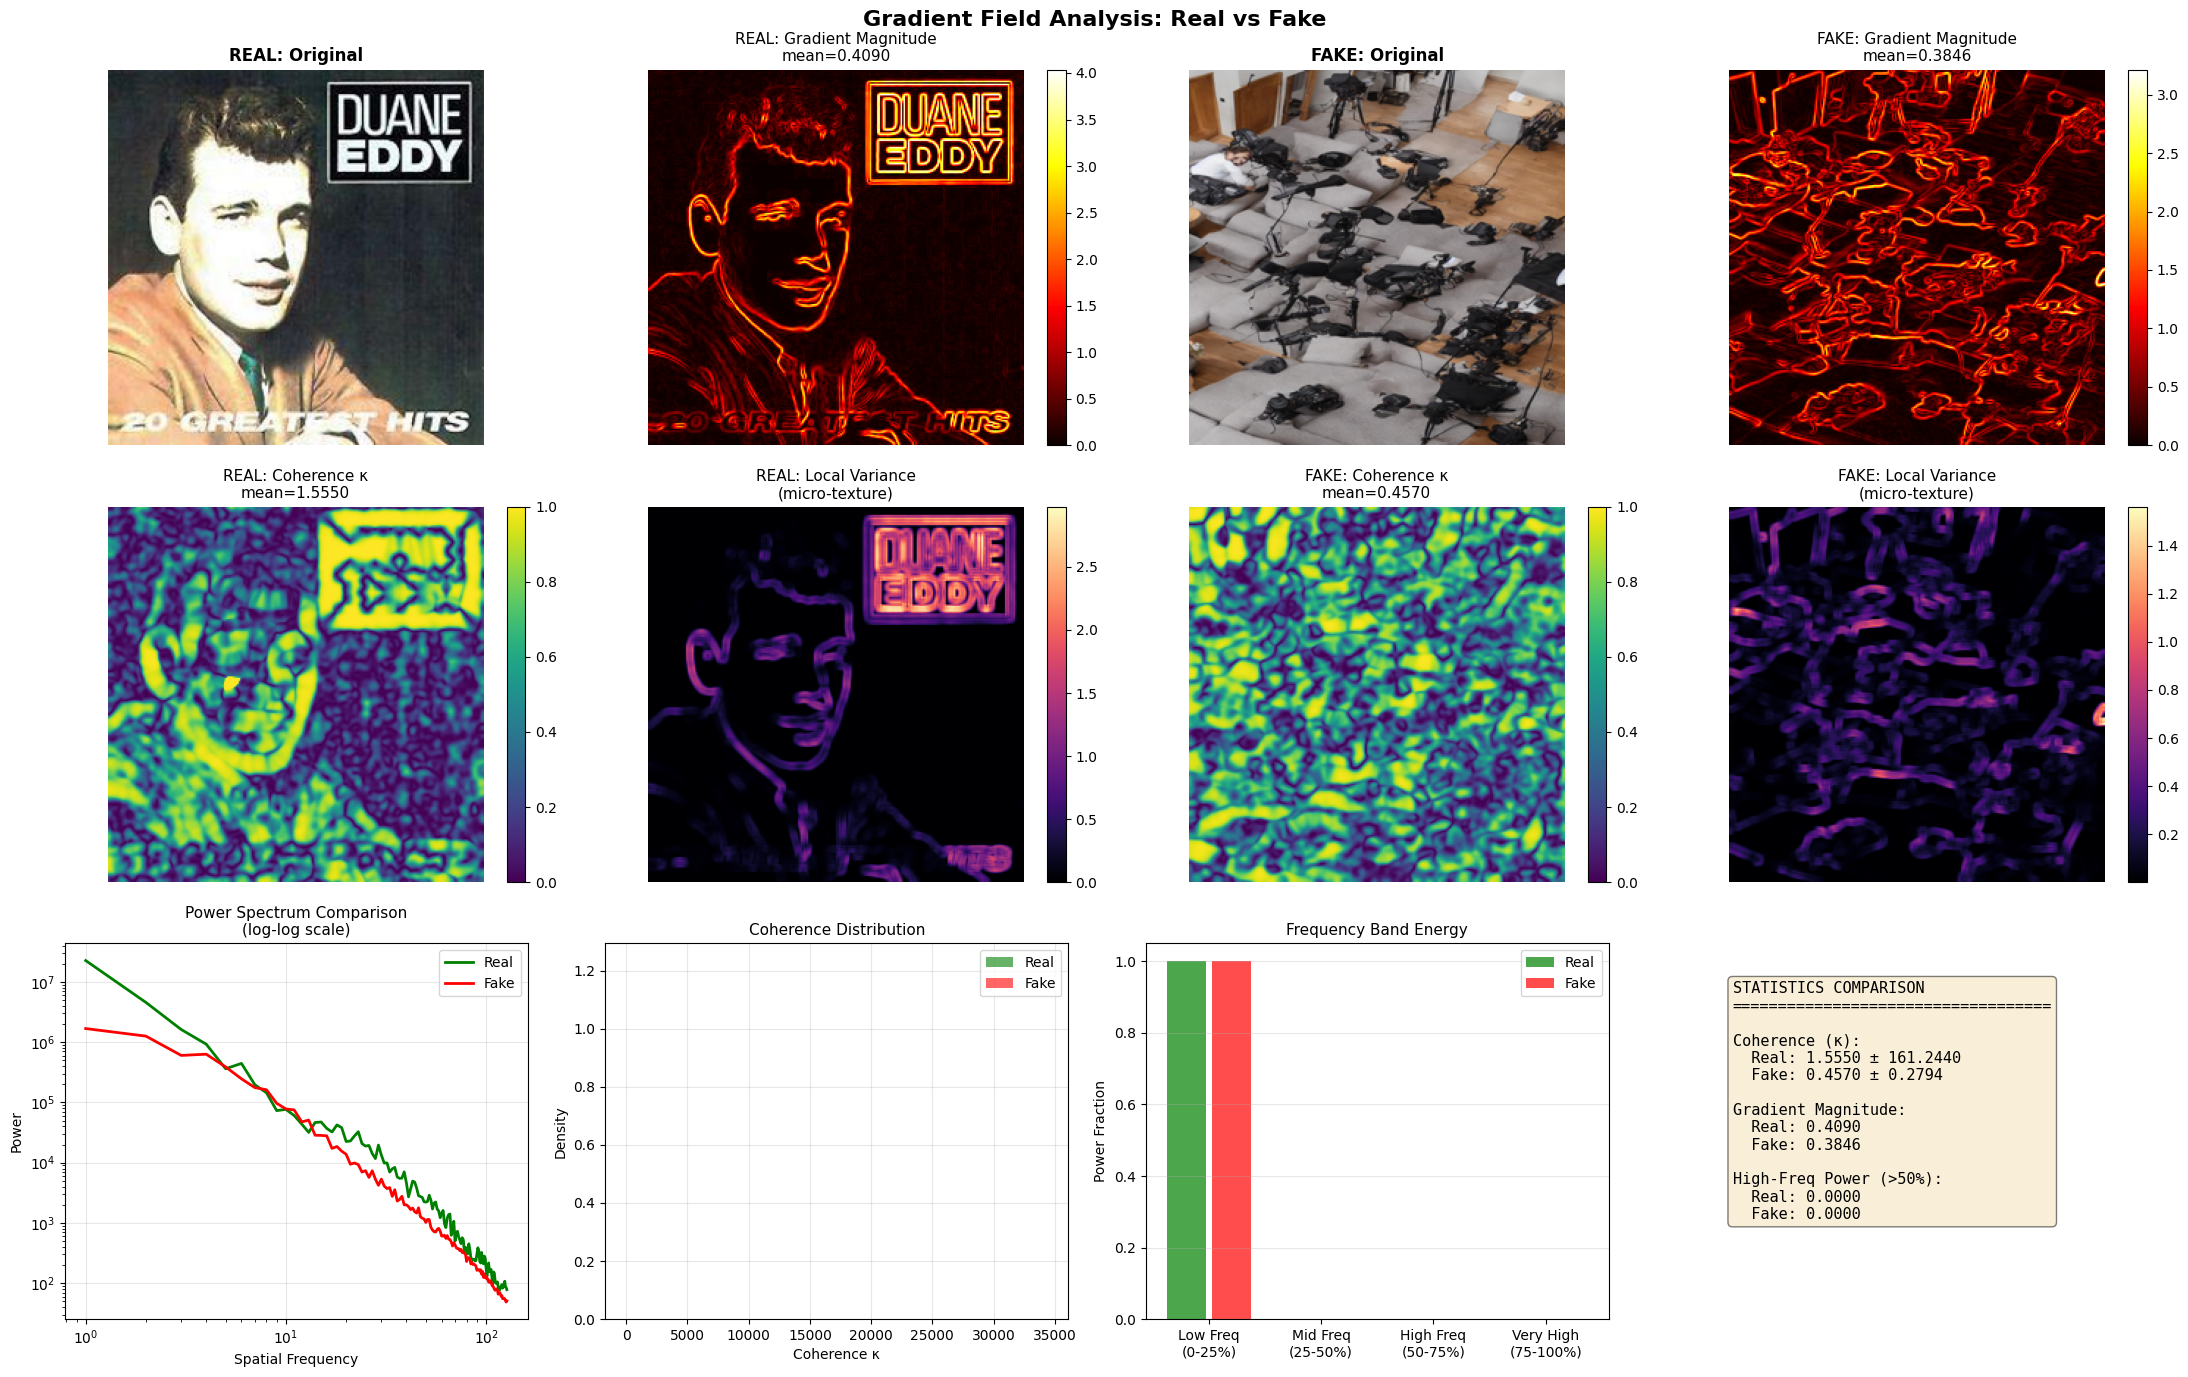

In [71]:
# Visualize real vs fake with coherence and power spectrum
if len(train_paths) > 0:
    real_sample = train_paths[train_labels.index(0)]
    fake_sample = train_paths[train_labels.index(1)]
    print(f"Real sample: {real_sample}")
    print(f"Fake sample: {fake_sample}")
    stats = visualize_gradient_comparison(real_sample, fake_sample)
else:
    print("No data found!")

In [72]:
# Try multiple pairs to see if pattern holds
print("\nComparing multiple samples...")
n_samples = min(5, len(train_paths)//2)

real_coherences = []
fake_coherences = []

for i in range(n_samples):
    # Get random real and fake
    real_idx = [j for j, l in enumerate(train_labels) if l == 0][i]
    fake_idx = [j for j, l in enumerate(train_labels) if l == 1][i]
    
    real_lum = load_and_preprocess(train_paths[real_idx])
    fake_lum = load_and_preprocess(train_paths[fake_idx])
    
    real_coh = compute_coherence(*compute_gradients(real_lum)).mean()
    fake_coh = compute_coherence(*compute_gradients(fake_lum)).mean()
    
    real_coherences.append(real_coh)
    fake_coherences.append(fake_coh)

print(f"\nMean Coherence across {n_samples} samples:")
print(f"  Real: {np.mean(real_coherences):.4f} ± {np.std(real_coherences):.4f}")
print(f"  Fake: {np.mean(fake_coherences):.4f} ± {np.std(fake_coherences):.4f}")

# Is there a difference?
diff = abs(np.mean(real_coherences) - np.mean(fake_coherences))
pooled_std = np.sqrt((np.std(real_coherences)**2 + np.std(fake_coherences)**2) / 2)
cohens_d = diff / (pooled_std + 1e-8)
print(f"  Cohen's d: {cohens_d:.3f} ({'Weak' if cohens_d < 0.5 else 'Moderate' if cohens_d < 0.8 else 'Strong'} effect)")


Comparing multiple samples...

Mean Coherence across 5 samples:
  Real: 1711857.3717 ± 3423713.2295
  Fake: 0.5385 ± 0.1044
  Cohen's d: 0.707 (Moderate effect)


---
## 6. PCA Modeling

In [73]:
# Extract features for all test images
print("Extracting gradient features from test set...")

X_test = []
for path in tqdm(test_paths):
    features = extract_gradient_features(path)
    X_test.append(features)

X_test = np.array(X_test)
y_test = np.array(test_labels)

print(f"\nFeature matrix shape: {X_test.shape}")

Extracting gradient features from test set...


100%|██████████| 100/100 [00:01<00:00, 76.78it/s]


Feature matrix shape: (100, 131072)


In [74]:
# Perform PCA
print("Performing PCA...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA Results:")
print(f"  Variance (PC1): {pca.explained_variance_ratio_[0]:.2%}")
print(f"  Variance (PC1+PC2): {sum(pca.explained_variance_ratio_[:2]):.2%}")
print(f"  Total: {sum(pca.explained_variance_ratio_):.2%}")

Performing PCA...

PCA Results:
  Variance (PC1): 1.41%
  Variance (PC1+PC2): 2.74%
  Total: 56.51%


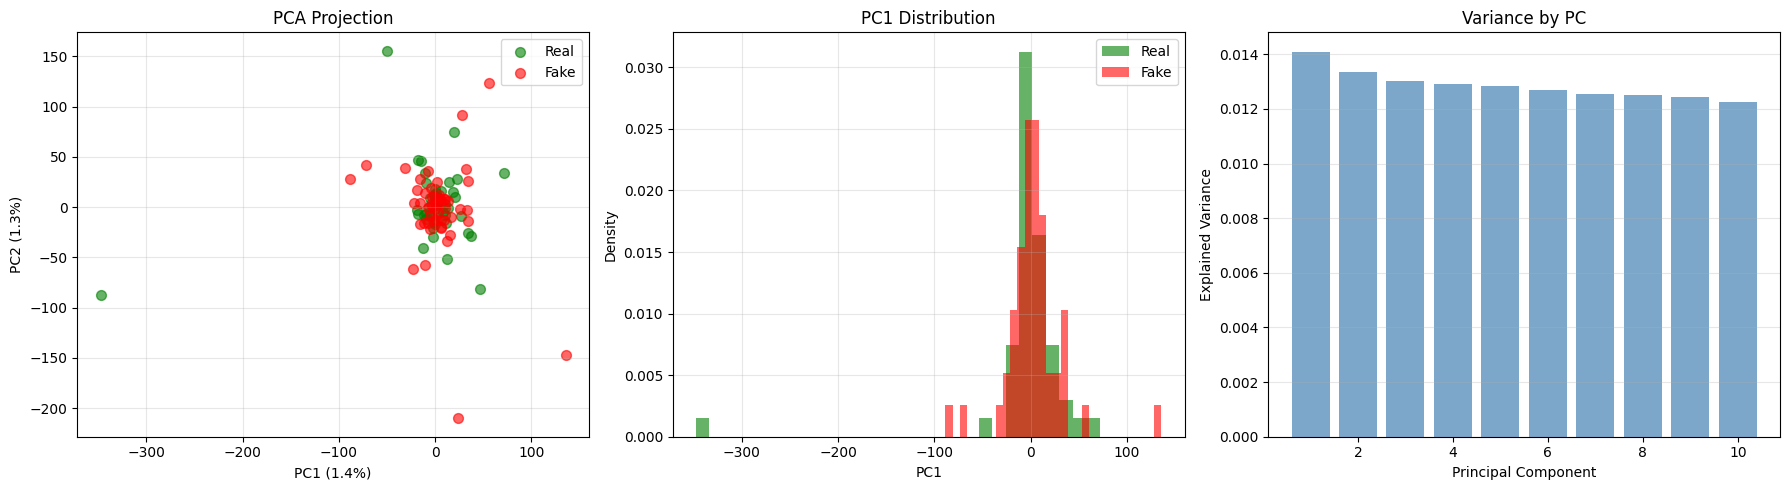

PC1: Cohen's d = 0.148
PC2: Cohen's d = 0.117
PC3: Cohen's d = 0.154


In [75]:
# PCA visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

real_mask = y_test == 0
fake_mask = y_test == 1

# Scatter
axes[0].scatter(X_pca[real_mask, 0], X_pca[real_mask, 1], c='green', alpha=0.6, label='Real', s=50)
axes[0].scatter(X_pca[fake_mask, 0], X_pca[fake_mask, 1], c='red', alpha=0.6, label='Fake', s=50)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA Projection')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PC1 distribution
axes[1].hist(X_pca[real_mask, 0], bins=30, alpha=0.6, color='green', label='Real', density=True)
axes[1].hist(X_pca[fake_mask, 0], bins=30, alpha=0.6, color='red', label='Fake', density=True)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('Density')
axes[1].set_title('PC1 Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Explained variance
axes[2].bar(range(1, 11), pca.explained_variance_ratio_[:10], color='steelblue', alpha=0.7)
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Explained Variance')
axes[2].set_title('Variance by PC')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Separation stats
for pc_idx in range(3):
    real_mean = X_pca[real_mask, pc_idx].mean()
    fake_mean = X_pca[fake_mask, pc_idx].mean()
    pooled_std = np.sqrt((X_pca[real_mask, pc_idx].std()**2 + X_pca[fake_mask, pc_idx].std()**2) / 2)
    d = abs(real_mean - fake_mean) / pooled_std
    print(f"PC{pc_idx+1}: Cohen's d = {d:.3f}")

---
## 7. Classification

In [76]:
# Logistic Regression on PCA features
K = 10
X_pca_k = X_pca[:, :K]

X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X_pca_k, y_test, test_size=0.3, random_state=42, stratify=y_test
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_lr, y_train_lr)

y_pred_lr = clf.predict(X_val_lr)
y_prob_lr = clf.predict_proba(X_val_lr)[:, 1]

print(f"{'='*50}")
print(f"LOGISTIC REGRESSION ({K} PCs)")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy_score(y_val_lr, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_val_lr, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_val_lr, y_pred_lr):.4f}")
print(f"F1:        {f1_score(y_val_lr, y_pred_lr):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_val_lr, y_prob_lr):.4f}")

print(f"\n{classification_report(y_val_lr, y_pred_lr, target_names=['Real', 'Fake'])}")

LOGISTIC REGRESSION (10 PCs)
Accuracy:  0.4333
Precision: 0.4667
Recall:    0.4375
F1:        0.4516
ROC AUC:   0.4286

              precision    recall  f1-score   support

        Real       0.40      0.43      0.41        14
        Fake       0.47      0.44      0.45        16

    accuracy                           0.43        30
   macro avg       0.43      0.43      0.43        30
weighted avg       0.44      0.43      0.43        30



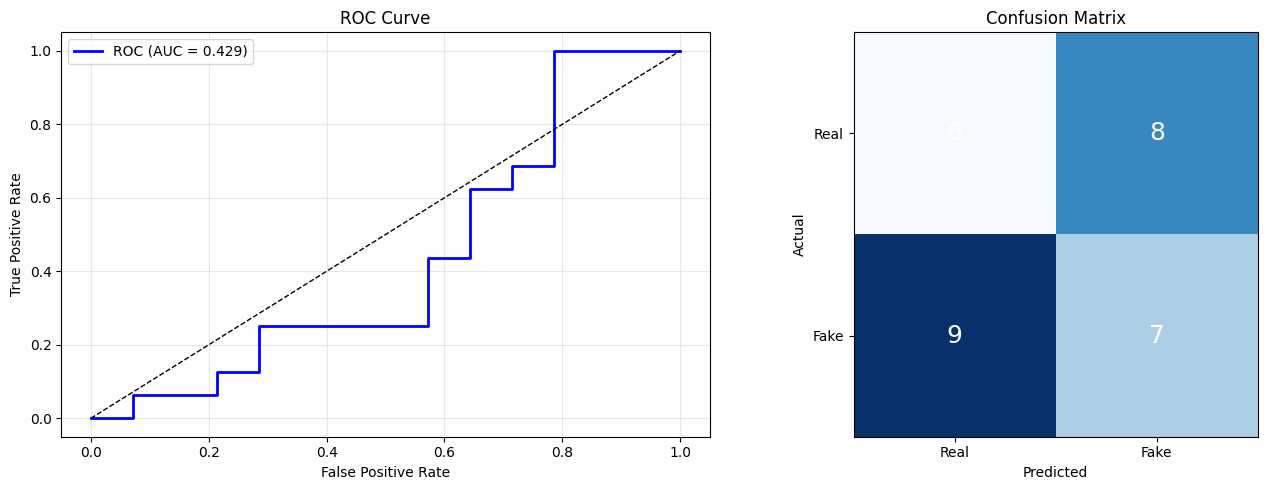

In [77]:
# ROC Curve and Confusion Matrix
fpr, tpr, _ = roc_curve(y_val_lr, y_prob_lr)
auc = roc_auc_score(y_val_lr, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_val_lr, y_pred_lr)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Real', 'Fake'])
axes[1].set_yticklabels(['Real', 'Fake'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()